In [1]:
import sys
sys.path.append("../../Classes")
from Solution import Solution
from Persistence import PersistMultipleSolutions, PersistSingleSolution
from utils import boxplot_fx, boxplot_convergence, get_fx_samples
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np

solutions = PersistMultipleSolutions().load(filename="vns_800",
                                            filepath="./results/")
optimum = PersistSingleSolution().load(filename="globopt_800",
                                      filepath="../global_optimum/solutions/")

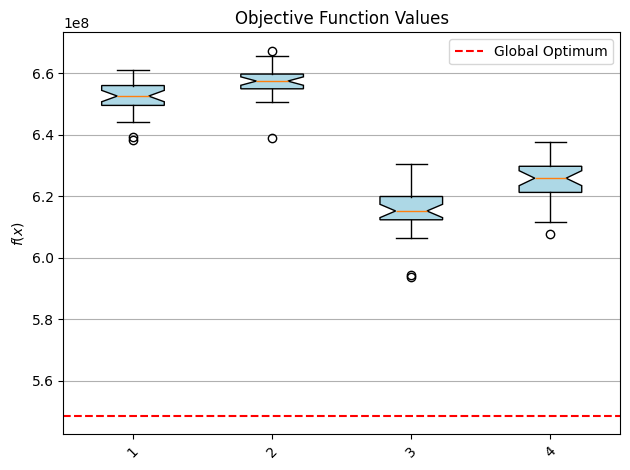

In [2]:
names = ["1", "2", "3", "4"]
boxplot_fx(solutions, names, global_optimum=optimum)

In [3]:
from scipy.stats import shapiro, ttest_ind
fx = get_fx_samples(solutions)
fx = [fx[2], fx[3]]  # Compare only algorithms 3 and 4
print("Shapiro-Wilk Test p-values:")
for i in range(len(fx)):
    stat, p = shapiro(fx[i])
    print(f"Algorithm {i+1}: {p:.4f}")

print("\nT-test p-value between Algorithm 1 and 2:")
stat, p = ttest_ind(fx[0], fx[1], equal_var=False, alternative='less')
print(f"{p:.4f}")

Shapiro-Wilk Test p-values:
Algorithm 1: 0.0671
Algorithm 2: 0.3561

T-test p-value between Algorithm 1 and 2:
0.0000


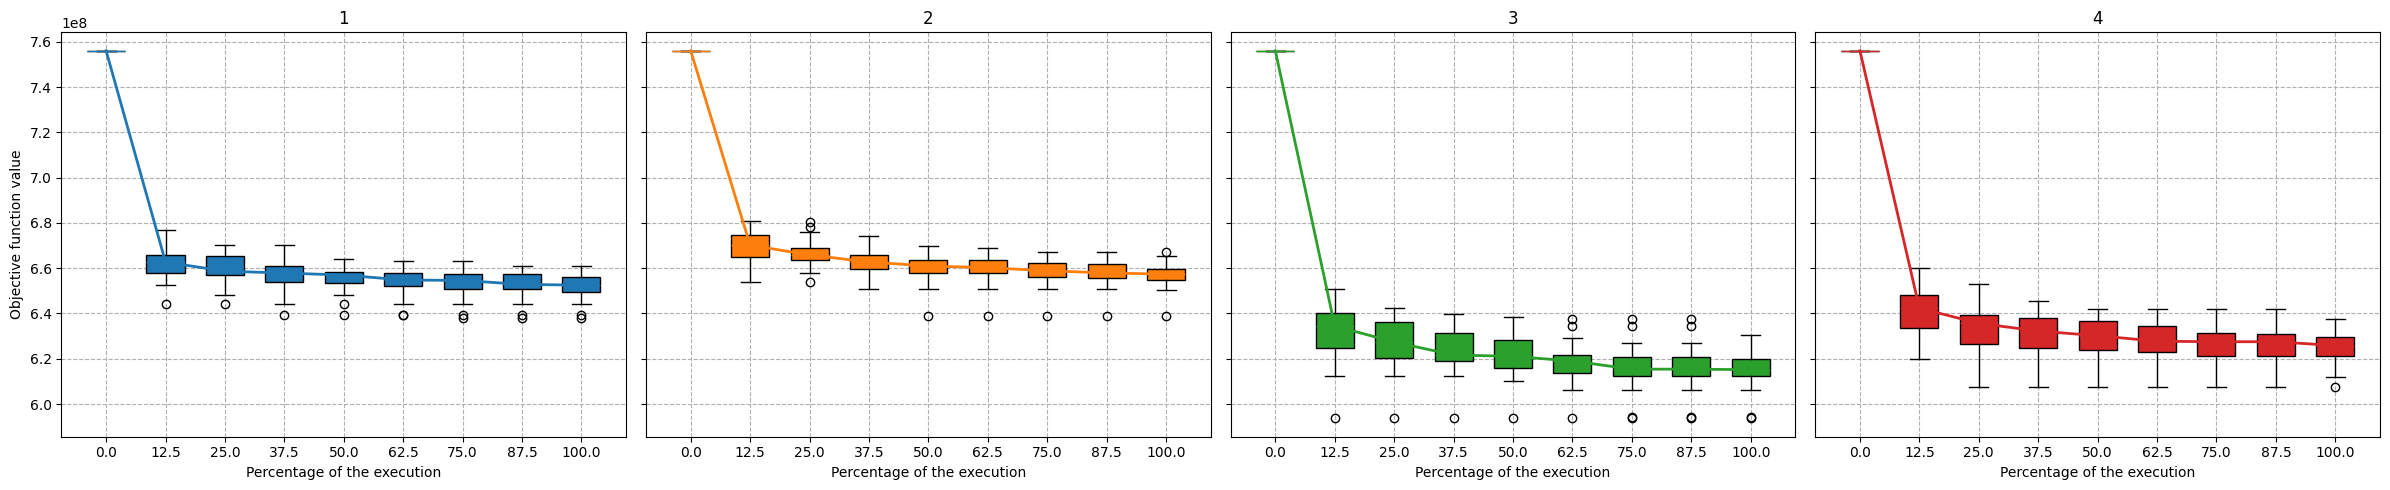

In [4]:
boxplot_convergence(solutions, names)